# 2. Gas dynamics in one dimension: Riemann problems, Godunov's method, and geometry

This notebook moves from linear advection to the Euler equations of an ideal gas. The new
ingredients are the **nonlinearity** of the system (shocks form by themselves and waves move at
speeds that depend on the solution) and the fact that it is a **system** of equations with three
families of waves. We will

1. look at the structure of the equations and of the Riemann problem, and at its exact solution;
2. build Godunov's method and compare the approximate Riemann solvers of Piastra;
3. go to higher order with reconstruction of primitive variables;
4. stress the schemes with strong shocks, near-vacuum states, and a shock hitting an entropy wave;
5. solve spherically and cylindrically symmetric problems, which requires geometric source terms.

It is useful, but not necessary, to go through the notebook on linear advection first.

In [1]:
import os, sys, io, contextlib
sys.path.insert(0, os.path.abspath('..'))          # the Piastra root directory

import numpy as np
import matplotlib.pyplot as plt

from src.parameters import Parameters
from src.grid.grid_setup import Grid
from src.sim_state import SimState
from src.misc.helpers import initial_model
from src.models.HD.HD_riemann_exact import exact_riemann_solution
from main import SOLVER_DISPATCH


def setup(problem, N, **options):
    '''Parameters, grid, initial state, EOS and solver for a 1D hydrodynamics problem.
    `options` are passed to Parameters: rec_type, RK_order, CFL, solver_type.'''
    with contextlib.redirect_stdout(io.StringIO()):
        par = Parameters(mode="HD", problem=problem, Nx1=N, Nx2=1, **options)
        grid = Grid(par.Nx1, par.Nx2, par.Ngc)
        state = SimState(grid, par)
        grid, state, par, eos = initial_model(grid, state, par)
        solver = SOLVER_DISPATCH["HD"](grid, state, eos, par)
    return grid, state, par, eos, solver


def evolve(solver, par, t_end=None):
    '''Advance the solution to t_end (default: the final time of the problem).'''
    if t_end is not None:
        par.timefin = t_end
    with contextlib.redirect_stdout(io.StringIO()):
        while par.timenow < par.timefin - 1e-12:
            state = solver.step_RK()
    return state


def profile(grid, array):
    '''Cell centres and values along x1 (interior cells of a 1D run).'''
    g = grid.Ngc
    return grid.cx1[g:-g, g], array[g:-g, g].copy()

## 1. The Euler equations

In one dimension the conservation laws for mass, momentum, and energy read

$$\frac{\partial}{\partial t}\begin{pmatrix}\rho\\ \rho u\\ E\end{pmatrix}
+ \frac{\partial}{\partial x}\begin{pmatrix}\rho u\\ \rho u^2 + p\\ (E + p)\,u\end{pmatrix} = 0,
\qquad E = \frac{\rho u^2}{2} + \frac{p}{\gamma - 1}.$$

The **conserved variables** $U = (\rho, \rho u, E)$ are what a finite-volume scheme updates;
the **primitive variables** $V = (\rho, u, p)$ are what we think in, and — as we shall see — what is
best reconstructed. Written in primitive form, the system has the characteristic speeds

$$\lambda_1 = u - c, \qquad \lambda_2 = u, \qquad \lambda_3 = u + c, \qquad c = \sqrt{\gamma p/\rho}.$$

Information travels along three families of characteristics: two acoustic waves and one
**entropy** (contact) wave that is simply carried with the flow. Because $\lambda_{1,3}$ depend on
the solution, compressive parts of an acoustic wave steepen and form **shocks**, across which the
Rankine–Hugoniot conditions (conservation of mass, momentum, and energy fluxes in the shock frame)
replace the differential equations. Expansive parts spread into **rarefaction fans**.

## 2. The Riemann problem

The Riemann problem is the initial-value problem with two constant states separated by a single
discontinuity. Its solution is **self-similar**, it depends on $x/t$ only, and consists of at most
three waves: a shock or a rarefaction on each side and a contact discontinuity in the middle, across
which pressure and velocity are continuous but density jumps. It can be computed exactly by solving
one nonlinear equation for the pressure between the waves (Toro 2009, ch. 4); Piastra contains this
solver. Here is the classic Sod problem, $(\rho, u, p) = (1, 0, 1)$ for $x < 0.5$ and
$(0.125, 0, 0.1)$ for $x > 0.5$, $\gamma = 1.4$:

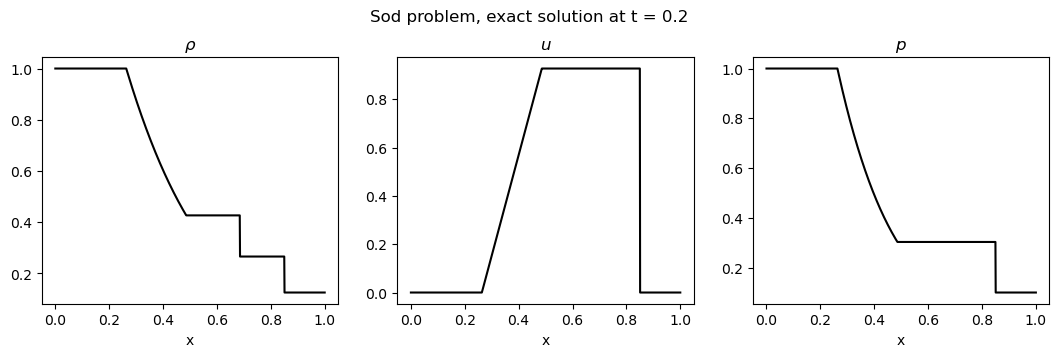

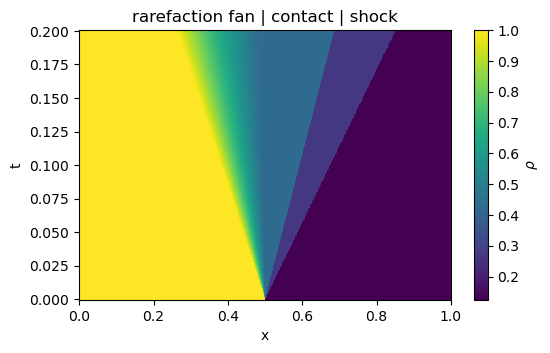

In [2]:
gamma = 1.4
sod = (1.0, 0.0, 1.0, 0.125, 0.0, 0.1)          # left (rho, u, p), right (rho, u, p)
x = np.linspace(0.0, 1.0, 1000)

rho, u, p = exact_riemann_solution(*sod, gamma, x, 0.2, x0=0.5)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, f, name in zip(axes, [rho, u, p], [r'$\rho$', '$u$', '$p$']):
    ax.plot(x, f, 'k'); ax.set_xlabel('x'); ax.set_title(name)
plt.suptitle('Sod problem, exact solution at t = 0.2', y=1.03)
plt.show()

# the same solution in the (x, t) plane: all waves are straight lines through (0.5, 0)
times = np.linspace(1e-4, 0.2, 200)
rho_xt = np.array([exact_riemann_solution(*sod, gamma, x, t, x0=0.5)[0] for t in times])
plt.figure(figsize=(6, 3.5))
plt.pcolormesh(x, times, rho_xt, shading='auto', cmap='viridis')
plt.colorbar(label=r'$\rho$')
plt.xlabel('x'); plt.ylabel('t')
plt.title('rarefaction fan | contact | shock')
plt.show()

From left to right: a rarefaction fan moving into the high-pressure gas, the contact discontinuity
(the former interface between the two gases, now moving right), and the shock running into the
low-pressure gas.

## 3. Godunov's method and approximate Riemann solvers

Godunov's idea (1959) is to treat the piecewise-constant cell averages as a sequence of Riemann
problems, one at each face. The flux through a face is the physical flux of the exact solution at
the face, $F_{i+1/2} = F\big(U^*(x/t = 0)\big)$, and the cell averages are updated with the
conservative formula from the advection notebook. For linear advection this is exactly the upwind
scheme.

Solving the exact Riemann problem at every face and every step is expensive and, for more complex
systems (MHD, relativity), impractical. **Approximate Riemann solvers** replace the exact wave
structure by a simpler one. Piastra implements

* **LLF** (local Lax–Friedrichs, Rusanov): a single wave speed $S = \max(|u| + c)$ on both sides,
  $F = \tfrac12\big[F_L + F_R - S\,(U_R - U_L)\big]$ — the most robust and the most dissipative;
* **HLL** (Harten, Lax & van Leer 1983): two waves with speeds $S_L < S_R$ and one averaged state
  between them — sharper, but still blind to the contact discontinuity;
* **HLLC** (Toro, Spruce & Speares 1994): three waves, restoring the contact;
* **Roe** (1981): the exact solution of a linearized problem, which resolves all three waves;
* **exact**: the exact Riemann solver of Section 2.

To isolate the effect of the solver, we use the first-order scheme (`rec_type='PCM'`, forward Euler)
and compare the five solvers on the Sod problem.

solver  L1 error of density, N = 200
LLF     0.0160
HLL     0.0111
HLLC    0.0103
Roe     0.0103
Exact   0.0099


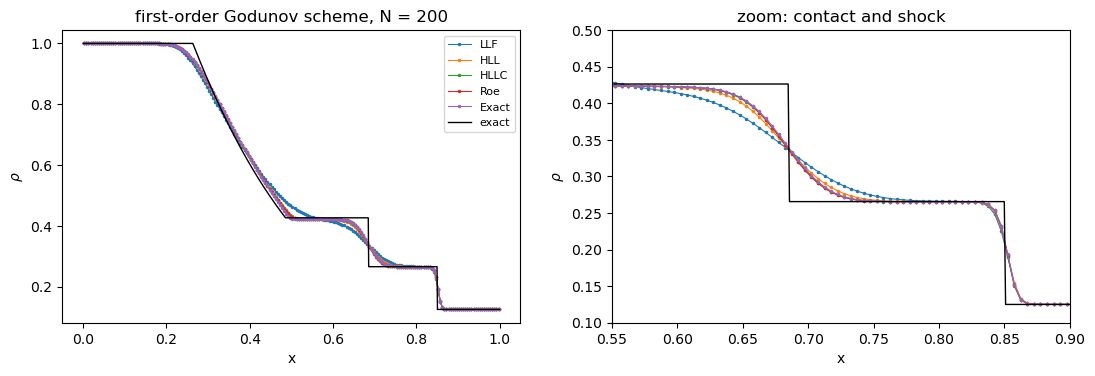

In [3]:
solvers = ['LLF', 'HLL', 'HLLC', 'Roe', 'Exact']
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
print(f"{'solver':6s}  L1 error of density, N = 200")
for s in solvers:
    grid, state, par, eos, solver = setup("sod1Dcart", 200, rec_type='PCM', RK_order='RK1',
                                           solver_type=s, CFL=0.7)
    state = evolve(solver, par)
    xc, rho_num = profile(grid, state.dens)
    rho_ex = exact_riemann_solution(*sod, gamma, xc, par.timenow, x0=0.5)[0]
    print(f"{s:6s}  {np.mean(np.abs(rho_num - rho_ex)):.4f}")
    for ax in axes:
        ax.plot(xc, rho_num, '.-', ms=3, lw=0.8, label=s)
for ax in axes:
    ax.plot(x, rho, 'k', lw=1, label='exact')
    ax.set_xlabel('x'); ax.set_ylabel(r'$\rho$')
axes[0].legend(fontsize=8); axes[0].set_title('first-order Godunov scheme, N = 200')
axes[1].set_xlim(0.55, 0.9); axes[1].set_ylim(0.1, 0.5); axes[1].set_title('zoom: contact and shock')
plt.show()

All solvers capture the shock in a few cells: shocks are **compressive**, the characteristics run
into them from both sides, and the numerical diffusion is counteracted by the steepening. The
**contact** is different. Its characteristics are parallel, nothing steepens it, and it is smeared
by the numerical diffusion like the Gaussian in the advection notebook — much more with LLF and HLL,
which do not know about the contact wave, than with HLLC, Roe, and the exact solver.

## 4. Higher order: reconstruction of primitive variables

Exactly as for advection, second order in space requires a reconstruction of the solution inside
each cell; the Riemann problems are then solved between the reconstructed face values. Piastra
reconstructs the **primitive** variables $(\rho, u, p)$ rather than the conserved ones. With
limited reconstruction each of them stays within the range of its neighbours, so the face states have
positive density and pressure; reconstructing $E$ and $\rho u$ instead gives no such guarantee for
$p = (\gamma-1)(E - \rho u^2/2)$. At a contact discontinuity, where $u$ and $p$ are constant,
reconstruction of primitives also keeps them exactly constant at the faces.

The resulting scheme — reconstruction, Riemann solver, Runge–Kutta integration — is the backbone of
all hyperbolic modules of Piastra.

reconstruction  L1 error of density, N = 200, HLLC
PCM + RK1       0.0112
PLM + RK2       0.0030
PPM + RK3       0.0016
WENO + RK3      0.0026
MP5 + RK3       0.0015


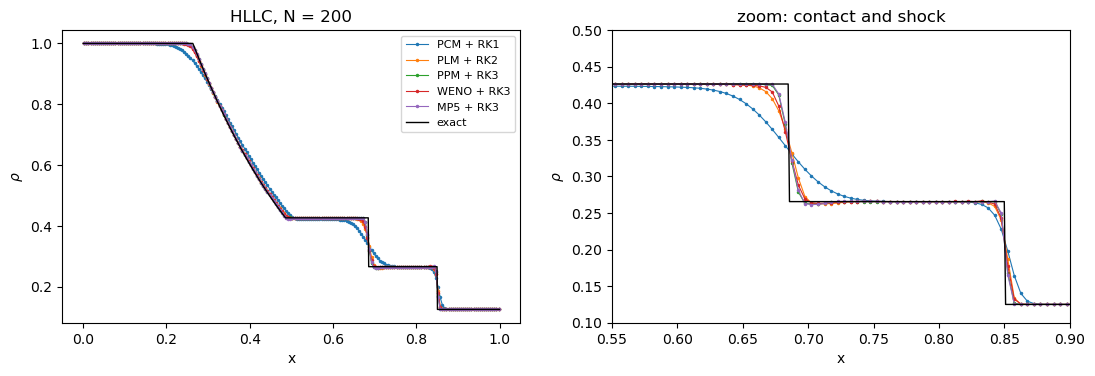

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
print(f"{'reconstruction':14s}  L1 error of density, N = 200, HLLC")
for rec, rk in [('PCM', 'RK1'), ('PLM', 'RK2'), ('PPM', 'RK3'), ('WENO', 'RK3'), ('MP5', 'RK3')]:
    grid, state, par, eos, solver = setup("sod1Dcart", 200, rec_type=rec, RK_order=rk,
                                           solver_type='HLLC', CFL=0.5)
    state = evolve(solver, par)
    xc, rho_num = profile(grid, state.dens)
    rho_ex = exact_riemann_solution(*sod, gamma, xc, par.timenow, x0=0.5)[0]
    print(f"{rec + ' + ' + rk:14s}  {np.mean(np.abs(rho_num - rho_ex)):.4f}")
    for ax in axes:
        ax.plot(xc, rho_num, '.-', ms=3, lw=0.8, label=f'{rec} + {rk}')
for ax in axes:
    ax.plot(x, rho, 'k', lw=1, label='exact')
    ax.set_xlabel('x'); ax.set_ylabel(r'$\rho$')
axes[0].legend(fontsize=8); axes[0].set_title('HLLC, N = 200')
axes[1].set_xlim(0.55, 0.9); axes[1].set_ylim(0.1, 0.5); axes[1].set_title('zoom: contact and shock')
plt.show()

For a solution with discontinuities the error is dominated by the few cells around the jumps, and
the different waves converge differently. A shock stays a few cells wide at any resolution, because
the characteristics steepen it, so its contribution to the $L_1$ error is $\propto \Delta x$. A contact
is smeared like a passive discontinuity in the advection notebook, with a width growing as
$\Delta x^{1/2}$ for a first-order scheme. The mixture gives an observed order between the two:

In [5]:
print(f"{'scheme':12s} L1 errors of density for N = 100, 200, 400, 800   -> orders")
for rec, rk in [('PCM', 'RK1'), ('PLM', 'RK2'), ('PPM', 'RK3')]:
    e = []
    for N in [100, 200, 400, 800]:
        grid, state, par, eos, solver = setup("sod1Dcart", N, rec_type=rec, RK_order=rk,
                                               solver_type='HLLC', CFL=0.5)
        state = evolve(solver, par)
        xc, rho_num = profile(grid, state.dens)
        e.append(np.mean(np.abs(rho_num - exact_riemann_solution(*sod, gamma, xc, par.timenow)[0])))
    print(f"{rec + ' + ' + rk:12s}", "  ".join(f"{v:.2e}" for v in e), "  ->",
          "  ".join(f"{np.log2(e[i] / e[i + 1]):.2f}" for i in range(3)))

scheme       L1 errors of density for N = 100, 200, 400, 800   -> orders
PCM + RK1    1.77e-02  1.12e-02  7.11e-03  4.49e-03   -> 0.66  0.66  0.66
PLM + RK2    5.56e-03  2.96e-03  1.64e-03  9.32e-04   -> 0.91  0.85  0.82
PPM + RK3    3.27e-03  1.60e-03  8.56e-04  4.88e-04   -> 1.03  0.90  0.81


The first-order scheme converges at about 2/3; the higher-order reconstructions converge faster
because they smear the contact less, but none of them reaches first order: the contact limits the rate.

## 5. Stress tests

Smooth flows and the Sod problem are forgiving. Three standard problems show where schemes break.

**A strong shock.** The problem `strong1D` has a pressure ratio of $10^5$ across the initial
discontinuity (Toro's test 3). The shock is preceded by a thin, very dense shell of shocked gas that
must be resolved by the scheme:

HLLC  N = 100: maximum density 4.59
LLF   N = 400: maximum density 5.97
HLLC  N = 400: maximum density 5.99
exact: maximum density 6.00


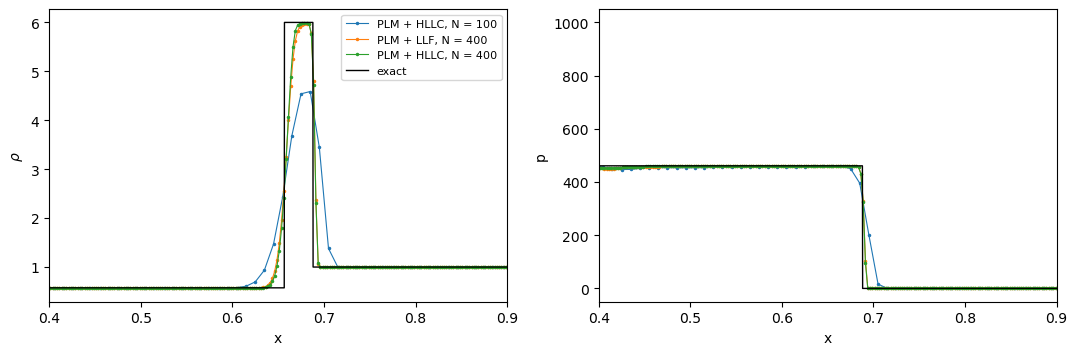

In [6]:
strong = (1.0, 0.0, 1000.0, 1.0, 0.0, 0.01)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for s, N in [('HLLC', 100), ('LLF', 400), ('HLLC', 400)]:
    grid, state, par, eos, solver = setup("strong1D", N, rec_type='PLM', RK_order='RK2',
                                           solver_type=s, CFL=0.5)
    state = evolve(solver, par)
    xc, rho_num = profile(grid, state.dens)
    xc, p_num = profile(grid, state.pres)
    axes[0].plot(xc, rho_num, '.-', ms=3, lw=0.8, label=f'PLM + {s}, N = {N}')
    axes[1].plot(xc, p_num, '.-', ms=3, lw=0.8, label=f'PLM + {s}, N = {N}')
    print(f"{s:5s} N = {N:3d}: maximum density {rho_num.max():.2f}")
xe = np.linspace(0, 1, 4000)
rho_e, u_e, p_e = exact_riemann_solution(*strong, gamma, xe, par.timenow, x0=0.5)
print(f"exact: maximum density {rho_e.max():.2f}")
axes[0].plot(xe, rho_e, 'k', lw=1, label='exact'); axes[1].plot(xe, p_e, 'k', lw=1)
axes[0].set_ylabel(r'$\rho$'); axes[1].set_ylabel('p')
for ax in axes:
    ax.set_xlim(0.4, 0.9); ax.set_xlabel('x')
axes[0].legend(fontsize=8)
plt.show()

The shell between the contact and the shock is only about 0.03 wide at this time. With $N = 400$
it spans a dozen cells and its density is captured well by both solvers; with $N = 100$ it spans three
cells and is badly underestimated. Thin post-shock shells are typical of strong shocks and radiative
flows, and they are one reason why astrophysical simulations often need higher resolution than the
smooth parts of the flow would suggest.

**A near-vacuum state.** In the 1-2-3 problem (`einfeldt1D`) two streams move apart at more than
twice the sound speed and leave behind a region of very low density and pressure. Linearized
(Roe-type) solvers are known to produce negative density or pressure in such flows (Einfeldt et al.
1991); the HLL family was designed to avoid it:

solver  min density  min pressure
LLF        2.51e-02      4.23e-03
HLL        2.40e-02      4.46e-03
HLLC       2.40e-02      4.46e-03
Roe        2.39e-02      4.46e-03
Exact      1.56e-02      3.04e-03
exact solution: minimum density 2.19e-02


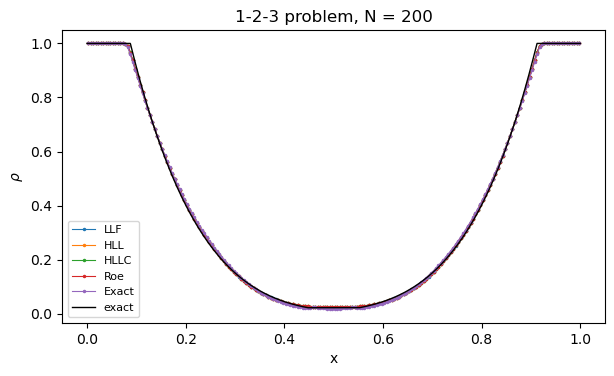

In [7]:
einfeldt = (1.0, -2.0, 0.4, 1.0, 2.0, 0.4)
plt.figure(figsize=(7, 3.8))
print(f"{'solver':6s} {'min density':>12s} {'min pressure':>13s}")
for s in solvers:
    grid, state, par, eos, solver = setup("einfeldt1D", 200, rec_type='PLM', RK_order='RK2',
                                           solver_type=s, CFL=0.5)
    try:
        state = evolve(solver, par)
        xc, rho_num = profile(grid, state.dens)
        xc, p_num = profile(grid, state.pres)
        ok = np.all(np.isfinite(rho_num))
        print(f"{s:6s} {rho_num.min():12.2e} {p_num.min():13.2e}" + ("" if ok else "   (NaN!)"))
        plt.plot(xc, rho_num, '.-', ms=3, lw=0.8, label=s)
    except Exception as err:
        print(f"{s:6s} failed: {type(err).__name__}")
xe = np.linspace(0, 1, 2000)
rho_e = exact_riemann_solution(*einfeldt, gamma, xe, 0.15, x0=0.5)[0]
print(f"exact solution: minimum density {rho_e.min():.2e}")
plt.plot(xe, rho_e, 'k', lw=1, label='exact')
plt.xlabel('x'); plt.ylabel(r'$\rho$'); plt.legend(fontsize=8); plt.title('1-2-3 problem, N = 200')
plt.show()

All solvers survive and stay positive here. The Roe solver of Piastra is protected by an
**entropy fix**: for the acoustic waves it uses the wave-speed estimates of Einfeldt, the extreme
of the Roe-averaged speed and of the speeds in the left and right states, which is also what makes
the HLL family robust. The approximate solvers fill the near-vacuum region by numerical diffusion and
leave a minimum density above the exact one; the scheme with the exact Riemann solver goes deeper.
Two remarks for the exercises. Piastra, like most codes, applies small **floors** to density and
pressure when converting conserved to primitive variables, so a scheme that "wants" to go negative can
be rescued silently; it is worth checking whether a floor was active. And the exact Riemann solver
assumes that no vacuum forms between the two states: for stronger expansions (try $u = \pm 4$) its
iteration breaks down.

**A shock meeting an entropy wave.** In the Shu–Osher problem (`shuosher1D`) a Mach-3 shock runs
into a sinusoidal density perturbation. Behind the shock the perturbation is compressed into
short waves, which a dissipative scheme smears out. There is no exact solution; we compare with a
reference computed on a fine grid:

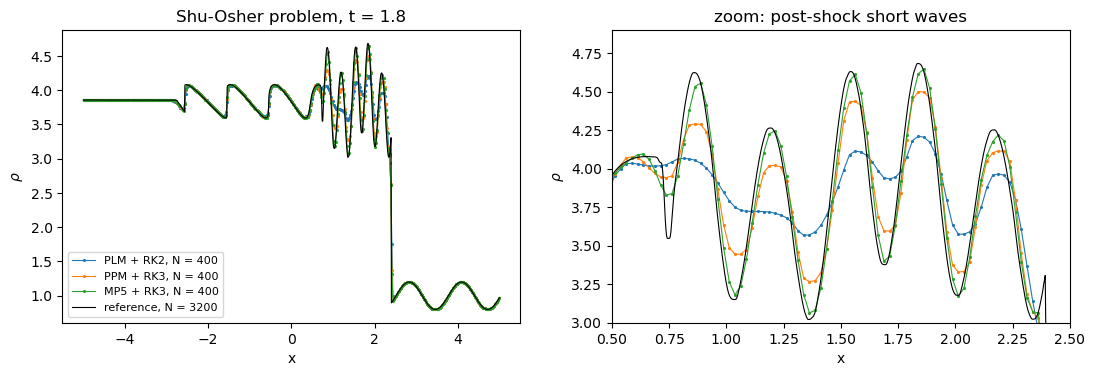

In [8]:
grid, state, par, eos, solver = setup("shuosher1D", 3200, rec_type='PPM', RK_order='RK3',
                                       solver_type='HLLC', CFL=0.5)
state = evolve(solver, par)
x_ref, rho_ref = profile(grid, state.dens)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for rec, rk in [('PLM', 'RK2'), ('PPM', 'RK3'), ('MP5', 'RK3')]:
    grid, state, par, eos, solver = setup("shuosher1D", 400, rec_type=rec, RK_order=rk,
                                           solver_type='HLLC', CFL=0.5)
    state = evolve(solver, par)
    for ax in axes:
        ax.plot(*profile(grid, state.dens), '.-', ms=2.5, lw=0.8, label=f'{rec} + {rk}, N = 400')
for ax in axes:
    ax.plot(x_ref, rho_ref, 'k', lw=0.8, label='reference, N = 3200')
    ax.set_xlabel('x'); ax.set_ylabel(r'$\rho$')
axes[0].legend(fontsize=8); axes[0].set_title('Shu-Osher problem, t = 1.8')
axes[1].set_xlim(0.5, 2.5); axes[1].set_ylim(3.0, 4.9); axes[1].set_title('zoom: post-shock short waves')
plt.show()

Here the benefit of high-order reconstruction is obvious: at the same resolution the short waves
behind the shock are much better preserved by PPM and MP5 than by PLM.

## 6. A little geometry: cylindrical and spherical symmetry

Many astrophysical flows are, to a first approximation, cylindrically or spherically symmetric:
explosions, winds, accretion. With $r$ the radius and $\alpha = 1$ (cylinder) or $\alpha = 2$
(sphere) the Euler equations become

$$\frac{\partial U}{\partial t} + \frac{1}{r^\alpha}\frac{\partial}{\partial r}\big(r^\alpha F\big) = S,
\qquad S = \begin{pmatrix}0\\ \alpha p/r\\ 0\end{pmatrix}.$$

The factor $r^\alpha$ inside the derivative is the area of a face; the **geometric source term**
$\alpha p / r$ appears because the pressure force acts on faces of different area. The finite-volume
form uses exact cell volumes $V_i$ and face areas $A_{i\pm1/2}$ ($V = \Delta r$, $\Delta(r^2)/2$,
$\Delta(r^3)/3$ and $A = 1$, $r$, $r^2$ for $\alpha = 0, 1, 2$):

$$\frac{d U_i}{dt} = -\frac{A_{i+1/2}F_{i+1/2} - A_{i-1/2}F_{i-1/2}}{V_i} + S_i .$$

A gas at rest with uniform pressure must stay at rest. The flux difference then gives
$p\,(A_{i+1/2} - A_{i-1/2})/V_i$, and the source must cancel it **exactly**, which fixes the radius
$r_i$ at which the source term is evaluated:

$$\frac{\alpha}{r_i} = \frac{A_{i+1/2} - A_{i-1/2}}{V_i}
\quad\Longrightarrow\quad
r_i = \frac{r_{i-1/2} + r_{i+1/2}}{2}\ (\alpha = 1), \qquad
r_i = \frac{2}{3}\,\frac{r_{i+1/2}^3 - r_{i-1/2}^3}{r_{i+1/2}^2 - r_{i-1/2}^2}\ (\alpha = 2).$$

Piastra defines the cell centre of spherical grids in exactly this way. To see why it matters we set
up a uniform gas at rest in spherical symmetry, once with the grid as it is and once with the cell
centres replaced by the arithmetic midpoints:

cell centre as defined by Piastra : max |v| after t = 0.5 is 3.3e-16
cell centre arithmetic midpoint   : max |v| after t = 0.5 is 2.1e-01


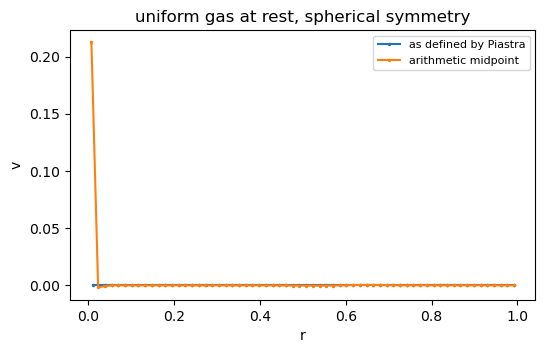

In [9]:
def radial_setup(geometry, N, **options):
    '''A 1D radial hydrodynamics set-up on [0, 1] in 'cartesian', 'cylindrical' or 'spherical'
    geometry. The state is filled with the Sod data; overwrite it as needed.'''
    with contextlib.redirect_stdout(io.StringIO()):
        par = Parameters(mode="HD", problem="sod1Dcart", Nx1=N, Nx2=1, **options)
        grid = Grid(par.Nx1, par.Nx2, par.Ngc)
        state = SimState(grid, par)
        grid, state, par, eos = initial_model(grid, state, par)
    if geometry == 'cylindrical':
        grid.CylindricalGrid(0.0, 1.0, 0.0, 1.0)              # (R, z) with one cell in z
    elif geometry == 'spherical':
        grid.SphericalPolarGrid(0.0, 1.0, 0.0, np.pi)         # (r, theta) with one cell in theta
    inner = grid.cx1 < 0.5
    state.dens[:, :] = np.where(inner, 1.0, 0.125)
    state.pres[:, :] = np.where(inner, 1.0, 0.1)
    state.vel1[:, :] = 0.0
    par.BC[:] = 'wall'                                        # reflection at r = 0 and at r = 1
    return grid, state, par, eos

plt.figure(figsize=(6, 3.5))
for centre in ['as defined by Piastra', 'arithmetic midpoint']:
    grid, state, par, eos = radial_setup('spherical', 64, rec_type='PLM', RK_order='RK2', solver_type='HLLC')
    if centre == 'arithmetic midpoint':
        grid.cx1[:, :] = 0.5 * (grid.fx1[:-1, :] + grid.fx1[1:, :])
    state.dens[:, :] = 1.0; state.pres[:, :] = 1.0; state.vel1[:, :] = 0.0
    solver = SOLVER_DISPATCH["HD"](grid, state, eos, par)
    state = evolve(solver, par, t_end=0.5)
    r, v = profile(grid, state.vel1)
    print(f"cell centre {centre:22s}: max |v| after t = 0.5 is {np.abs(v).max():.1e}")
    plt.plot(r, v, '.-', ms=3, label=centre)
plt.xlabel('r'); plt.ylabel('v'); plt.legend(fontsize=8)
plt.title('uniform gas at rest, spherical symmetry')
plt.show()

With the balanced cell centre the gas stays at rest to round-off. With the arithmetic midpoint the
pressure force and the geometric source no longer cancel, and a spurious flow of order $0.1\,c$
develops near the origin, where the relative difference between the two definitions of $r_i$ is
largest. Such **well-balanced** formulations — discretizations that preserve an equilibrium exactly —
are essential whenever a small dynamical effect has to be followed on top of a large balance of
forces, as in stellar interiors or accretion disks.

Now the Sod problem as a cylindrical and a spherical "explosion": the high-pressure gas initially
fills $r < 0.5$.

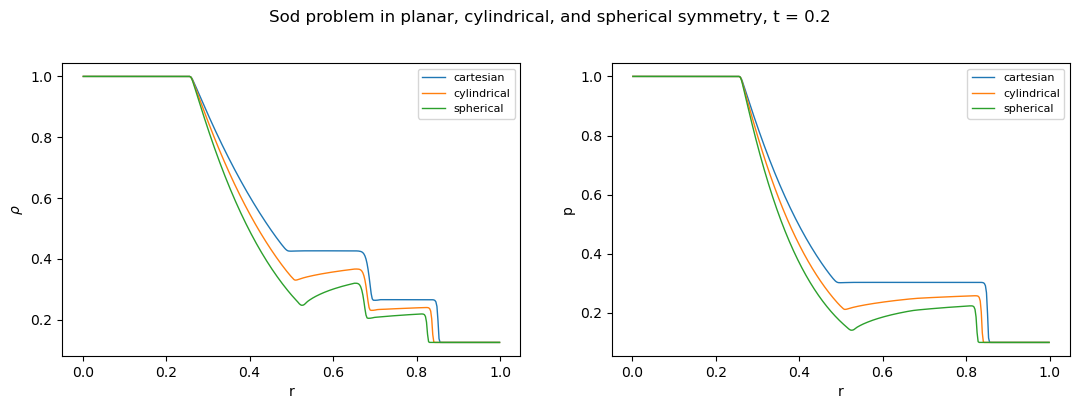

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for geometry in ['cartesian', 'cylindrical', 'spherical']:
    grid, state, par, eos = radial_setup(geometry, 400, rec_type='PLM', RK_order='RK2', solver_type='HLLC')
    solver = SOLVER_DISPATCH["HD"](grid, state, eos, par)
    state = evolve(solver, par, t_end=0.2)
    axes[0].plot(*profile(grid, state.dens), lw=1, label=geometry)
    axes[1].plot(*profile(grid, state.pres), lw=1, label=geometry)
axes[0].set_ylabel(r'$\rho$'); axes[1].set_ylabel('p')
for ax in axes:
    ax.set_xlabel('r'); ax.legend(fontsize=8)
plt.suptitle('Sod problem in planar, cylindrical, and spherical symmetry, t = 0.2', y=1.02)
plt.show()

In the planar case the shock moves at constant speed and the region between the contact and the
shock is uniform. In diverging geometry the energy behind the shock is spread over a growing area
($\propto r^\alpha$), so the shock weakens and slows down, and the flow behind it is no longer uniform.
Behind the contact a pressure minimum forms; in the spherical case it steepens into a secondary shock
that later moves inward. The rarefaction moving inward will converge on the axis or the centre and be
reflected there (run to $t = 0.5$ to see it). None of these problems has a simple exact solution; a
good check is a run on a much finer grid.

## Summary

* The Euler equations carry three families of waves; the Riemann problem combines them in a
  self-similar solution that can be computed exactly.
* Godunov's method solves a Riemann problem at every face. Approximate solvers differ mainly in how
  well they resolve the contact discontinuity: LLF and HLL smear it, HLLC, Roe and the exact solver
  keep it sharp.
* High order comes from reconstructing primitive variables; it pays off most in problems with
  fine smooth structure (Shu–Osher) and least at isolated discontinuities.
* Strong shocks and near-vacuum states test robustness; floors can hide failures.
* In curvilinear geometry the geometric source terms must be discretized consistently with the
  fluxes, otherwise even a gas at rest starts to move.

## Exercises

1. Set up Toro's test 1, $(\rho, u, p) = (1, 0.75, 1) \,|\, (0.125, 0, 0.1)$, as a user-defined
   problem. Its rarefaction is **transonic** (it contains a point where $u = c$). Remove the entropy
   fix from `Roe_flux` in `src/models/HD/HD_riemann_approx.py` (use the Roe-averaged speeds
   $\tilde u \mp \tilde c$ alone) and look for the unphysical "expansion shock" in the rarefaction.
2. Find the largest Courant number for which PLM + HLLC with RK2 still solves the strong shock
   problem, and compare with RK3.
3. Add a counter to the conversion from conserved to primitive variables that records how often the
   density or pressure floor is used, and repeat the 1-2-3 test with all solvers.
4. Run the spherical Sod problem at $N = 200, 400, 800, 1600$ and use the finest run as a reference to
   measure the convergence order. Is it the same as in the planar case?
5. Increase the velocities of the 1-2-3 problem to $u = \pm 4$, where a vacuum forms. Which solvers
   survive? Extend the exact Riemann solver with the vacuum case (Toro 2009, Sect. 4.6).